In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

np.random.seed(42)

#We're creating a dataset of 200 customers with Age and Income, then finding natural groups.

--->Now create 3 customer groups:

In [3]:
# GROUP 1: Budget customers (young, low income)
budget=np.random.normal(loc=[25,30000],scale=[5,5000],size=[70,2])

Explanation:

loc=[25, 30000] = Center point: Age 25, Income $30K
scale=[5, 5000] = Spread around center

Age spreads ±5 years (so 20-30 years old)
Income spreads ±5000 (so $25K-35K)


size=(70, 2) = Create 70 customers with 2 features (Age, Income)

Result: 70 young, poor customers

In [4]:
# GROUP 2: Mid-tier customers (middle aged, medium income)
mid = np.random.normal(loc=[40, 60000], scale=[7, 8000], size=(70, 2))    

Explanation:

Age center: 40 years old (middle aged)
Income center: $60K (medium)
70 customers in this group

Result: 70 middle-aged customers with medium income

In [5]:
# GROUP 3: Premium customers (older, high income)
premium = np.random.normal(loc=[55, 100000], scale=[8, 15000], size=(60, 2))

Explanation:

Age center: 55 years old
Income center: $100K (high)
60 customers in this group

Result: 60 older, rich customers

In [6]:
# Combine all three groups:
X=np.vstack([budget,mid,premium])

What is vstack?

Stack arrays vertically (one on top of other)
Result: 200 rows × 2 columns

In [ ]:
budget:  70 customers
mid:     70 customers  
premium: 60 customers
────────────────────
X:      200 customers total

In [7]:
df=pd.DataFrame(X,columns=['age','salary'])

In [8]:
df.head()

,age,salary
0,27.483571,29308.678494
1,28.238443,37615.149282
2,23.829233,28829.315215
3,32.896064,33837.173646
4,22.652628,32712.800218


In [9]:
df.shape

(200, 2)

At this point: You have data with 3 hidden groups, but K-Means doesn't know that yet!

STEP 2: Standardize Data (CRUCIAL!)

In [11]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(df)

Why standardize?

Without scaling:
Age: 20-60 (small numbers, range=40)
Income: 10K-150K (huge numbers, range=140K)

Distance calculation ignores age because income is so big!

After scaling:
Both Age and Income become -1 to 1 range

Now both matter equally in distance calculation!

In [12]:
print("Mean:", X_scaled.mean(axis=0))  # Should be ~[0, 0]
print("Std:", X_scaled.std(axis=0))    # Should be ~[1, 1]

Mean: [ 2.66453526e-17 -4.28546088e-16]
Std: [1. 1.]


STEP 3: Find Optimal K (Elbow Method)
Question: How many groups should we find? 2? 3? 5? 10?
Solution: Try all and see which is best!

In [14]:
import warnings
warnings.filterwarnings('ignore')

inertias = []
K_range = range(1, 11)  # Try k=1,2,3...10

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

In [15]:
print("K-Means Inertia for different k values:")
for k, inertia in zip(K_range, inertias):
    print(f"k={k}   →   Inertia: {inertia:.2f}")

K-Means Inertia for different k values:
k=1   →   Inertia: 400.00
k=2   →   Inertia: 125.06
k=3   →   Inertia: 53.82
k=4   →   Inertia: 43.68
k=5   →   Inertia: 34.10
k=6   →   Inertia: 29.81
k=7   →   Inertia: 25.77
k=8   →   Inertia: 22.43
k=9   →   Inertia: 19.66
k=10   →   Inertia: 17.22


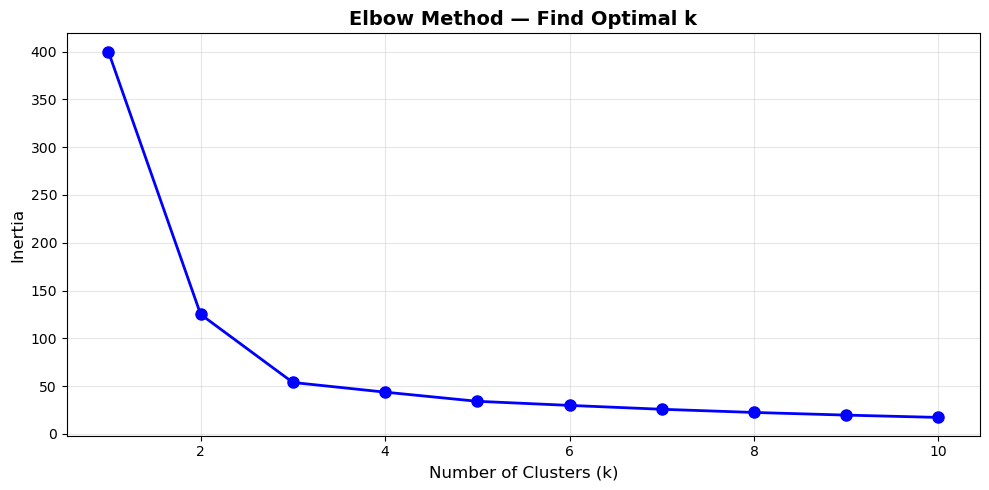

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.title('Elbow Method — Find Optimal k', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

k=1 → k=2:  Drop = 400 - 125 = 275  ← HUGE DROP! ✓✓✓
k=2 → k=3:  Drop = 125 - 54 = 71    ← BIG DROP! ✓✓
k=3 → k=4:  Drop = 54 - 44 = 10     ← Small drop
k=4 → k=5:  Drop = 44 - 34 = 10     ← Small drop
k=5 → k=6:  Drop = 34 - 30 = 4      ← Tiny drop
k=6 → k=7:  Drop = 30 - 26 = 4      ← Tiny drop

# Notice the pattern?
Large drops (k=1→2→3)
Then small drops (k=4 onwards)

The ELBOW is at k=3!

Because:

Before k=3: Big improvements
After k=3: Tiny improvements (not worth adding more clusters)

In [19]:
# Train K-Means with k=3 (from elbow method)
model = KMeans(
    n_clusters=3,        # We chose 3 from elbow method
    random_state=42,     # For reproducibility
    n_init=10            # Try 10 different starting positions
)

clusters = model.fit_predict(X_scaled)

In [21]:
df['Clusters']=clusters

print("Cluster distribution:")
print(df['Clusters'].value_counts().sort_index())

Cluster distribution:
Clusters
0    72
1    57
2    71
Name: count, dtype: int64


In [22]:
centers_scaled = model.cluster_centers_

# What is this?

# cluster_centers_ = The final position of the 3 centers (in SCALED space)
# Each center is the "average point" of its cluster


In [23]:
centers_scaled

array([[ 0.06011713,  0.00294779],
       [ 1.23417138,  1.32389053],
       [-1.05177749, -1.065831  ]])

Problem: These numbers are in SCALED space (weird numbers like -0.45). We want to see them in ORIGINAL scale (actual Age and Income).


#Convert centers back to original scale:

In [24]:
centers_original = scaler.inverse_transform(centers_scaled)

print("Cluster Centers (ORIGINAL SCALE):")
print(centers_original)

Cluster Centers (ORIGINAL SCALE):
[[4.03120372e+01 6.20198362e+04]
 [5.72721820e+01 1.01445355e+05]
 [2.42498373e+01 3.01205287e+04]]


In [25]:
print("\n" + "="*60)
print("CLUSTER CENTERS (What each cluster represents)")
print("="*60)

for i, center in enumerate(centers_original):
    print(f"\nCluster {i}:")
    print(f"  Average Age: {center[0]:.1f} years")
    print(f"  Average Income: ${center[1]:.0f}")


CLUSTER CENTERS (What each cluster represents)

Cluster 0:
  Average Age: 40.3 years
  Average Income: $62020

Cluster 1:
  Average Age: 57.3 years
  Average Income: $101445

Cluster 2:
  Average Age: 24.2 years
  Average Income: $30121


In [29]:
print(df.columns)
print(df.head())

Index(['age', 'salary', 'Clusters'], dtype='object')
         age        salary  Clusters
0  27.483571  29308.678494         2
1  28.238443  37615.149282         2
2  23.829233  28829.315215         2
3  32.896064  33837.173646         2
4  22.652628  32712.800218         2


In [30]:
# ═══════════════════════════════════════════════════════════
# STEP 4: Train K-Means with k=3
# ═══════════════════════════════════════════════════════════

model = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = model.fit_predict(X_scaled)
df['Cluster'] = clusters  # ← This adds the Cluster column!

print("Cluster distribution:")
print(df['Cluster'].value_counts().sort_index())
print(df.head())  # Should now show Age, Annual_Income, Cluster

Cluster distribution:
Cluster
0    72
1    57
2    71
Name: count, dtype: int64
         age        salary  Clusters  Cluster
0  27.483571  29308.678494         2        2
1  28.238443  37615.149282         2        2
2  23.829233  28829.315215         2        2
3  32.896064  33837.173646         2        2
4  22.652628  32712.800218         2        2


In [31]:
plt.figure(figsize=(12, 7))

# Plot each cluster with different color
colors = ['red', 'green', 'blue']

for cluster_id in range(3):
    mask = df['Clusters'] == cluster_id
    plt.scatter(df[mask]['Age'], df[mask]['Annual_Income'], 
               label=f'Cluster {cluster_id}', 
               s=100, alpha=0.6, color=colors[cluster_id])

# Plot cluster centers
plt.scatter(centers_original[:, 0], centers_original[:, 1], 
           marker='X', s=500, c='black', edgecolors='yellow', 
           linewidth=2, label='Centroids', zorder=5)

plt.xlabel('Age', fontsize=12)
plt.ylabel('Annual Income ($)', fontsize=12)
plt.title('Customer Segmentation — K-Means Clustering (k=3)', 
         fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

KeyError: 'Age'

<Figure size 1200x700 with 0 Axes>

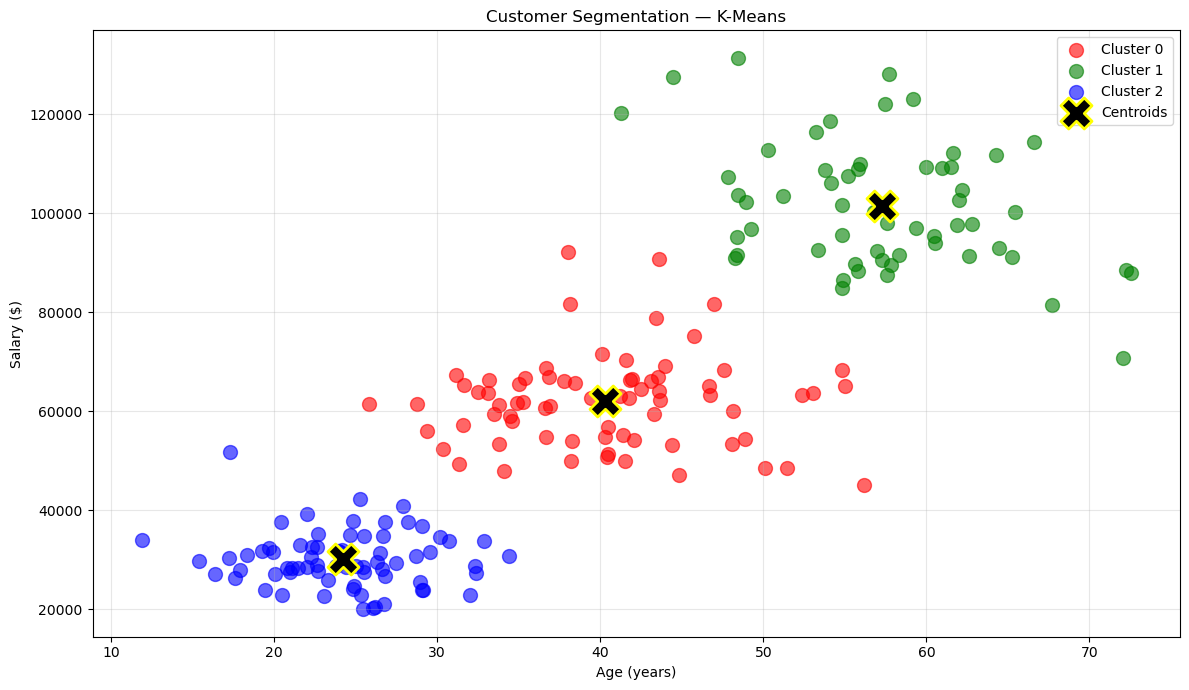

In [32]:
plt.figure(figsize=(12, 7))
colors = ['red', 'green', 'blue']

for cluster_id in range(3):
    mask = df['Clusters'] == cluster_id    # ← 'Clusters' (your column name)
    plt.scatter(df[mask]['age'], df[mask]['salary'],   # ← 'age' and 'salary'
               label=f'Cluster {cluster_id}', s=100, alpha=0.6, 
               color=colors[cluster_id])

plt.scatter(centers_original[:, 0], centers_original[:, 1], 
           marker='X', s=500, c='black', edgecolors='yellow', 
           linewidth=2, label='Centroids', zorder=5)

plt.xlabel('Age (years)')
plt.ylabel('Salary ($)')
plt.title('Customer Segmentation — K-Means')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [33]:
print("\n" + "="*70)
print("CUSTOMER PROFILES")
print("="*70)

for cluster_id in range(3):
    cluster_data = df[df['Clusters'] == cluster_id]  # ← 'Clusters'
    print(f"\nCluster {cluster_id}:")
    print(f"  Count: {len(cluster_data)}")
    print(f"  Avg Age: {cluster_data['age'].mean():.1f}")        # ← 'age'
    print(f"  Avg Salary: ${cluster_data['salary'].mean():.0f}")  # ← 'salary'
    print(f"  Age Range: {cluster_data['age'].min():.0f}-{cluster_data['age'].max():.0f}")
    print(f"  Salary Range: ${cluster_data['salary'].min():.0f}-${cluster_data['salary'].max():.0f}")


CUSTOMER PROFILES

Cluster 0:
  Count: 72
  Avg Age: 40.3
  Avg Salary: $62020
  Age Range: 26-56
  Salary Range: $45062-$92114

Cluster 1:
  Count: 57
  Avg Age: 57.3
  Avg Salary: $101445
  Age Range: 41-73
  Salary Range: $70719-$131386

Cluster 2:
  Count: 71
  Avg Age: 24.2
  Avg Salary: $30121
  Age Range: 12-34
  Salary Range: $20062-$51805


In [34]:
# ═══════════════════════════════════════════════════════════
# STEP 8: Evaluate
# ═══════════════════════════════════════════════════════════

print("\n" + "="*70)
print("CLUSTERING QUALITY")
print("="*70)
print(f"Inertia: {model.inertia_:.2f}")
print(f"Silhouette Score: {silhouette_score(X_scaled, clusters):.4f}")


CLUSTERING QUALITY
Inertia: 53.82
Silhouette Score: 0.5951


----------------------------------------------

In [35]:
# Create 5 random new customers
new_customers = [
    [30, 50000],    # Young, medium income
    [55, 95000],    # Old, high income
    [23, 28000],    # Very young, low income
    [45, 65000],    # Middle age, medium income
    [60, 120000],   # Very old, very high income
]

# Convert to DataFrame
new_df = pd.DataFrame(new_customers, columns=['age', 'salary'])

print("New customers to predict:")
print(new_df)

New customers to predict:
   age  salary
0   30   50000
1   55   95000
2   23   28000
3   45   65000
4   60  120000


In [36]:
# Scale using the SAME scaler we trained on
new_scaled = scaler.transform(new_df)  # Use transform, not fit_transform!

print("\nScaled data:")
print(new_scaled)


Scaled data:
[[-0.65372648 -0.39977399]
 [ 1.07688115  1.10794042]
 [-1.13829661 -1.13687881]
 [ 0.3846381   0.10279748]
 [ 1.42300268  1.94555953]]


Why use scaler.transform and not fit_transform?

fit_transform = Learn scale from this data (WRONG)
transform = Use the scale we learned from training data (CORRECT)

In [37]:
predictions = model.predict(new_scaled)

print("\n" + "="*60)
print("PREDICTIONS")
print("="*60)

for i, (customer, cluster) in enumerate(zip(new_customers, predictions)):
    age, salary = customer
    print(f"\nCustomer {i+1}: Age={age}, Salary=${salary}")
    print(f"  → Assigned to Cluster {cluster}")
    
    # Show which segment this is
    if cluster == 0:
        print(f"     (Middle-tier customer)")
    elif cluster == 1:
        print(f"     (Premium customer)")
    else:
        print(f"     (Budget customer)")


PREDICTIONS

Customer 1: Age=30, Salary=$50000
  → Assigned to Cluster 2
     (Budget customer)

Customer 2: Age=55, Salary=$95000
  → Assigned to Cluster 1
     (Premium customer)

Customer 3: Age=23, Salary=$28000
  → Assigned to Cluster 2
     (Budget customer)

Customer 4: Age=45, Salary=$65000
  → Assigned to Cluster 0
     (Middle-tier customer)

Customer 5: Age=60, Salary=$120000
  → Assigned to Cluster 1
     (Premium customer)
